<a href="https://colab.research.google.com/github/ouchn2580201251107/04399_Big_Data_Analytics_Mining_Tech/blob/main/04399_BigData_Ex5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 导入 Library
import numpy as np
import pandas as pd
from sklearn import cluster
import matplotlib.pyplot as plt

%matplotlib inline

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
vertebrate=pd.read_csv('/content/drive/MyDrive/04399_Big_Data_Analytics&Mining_Tech/data/vertebrate.csv',header='infer')
vertebrate.head()

,Name,Warm-blooded,Gives Birth,Aquatic Creature,Aerial Creature,Has Legs,Hibernates,Class
0,human,1,1,0,0,1,0,mammals
1,python,0,0,0,0,0,1,reptiles
2,salmon,0,0,1,0,0,0,fishes
3,whale,1,1,1,0,0,0,mammals
4,frog,0,0,1,0,1,1,amphibians


In [ ]:
X = vertebrate.drop(['Name','Class'],axis=1)
k_means = cluster.KMeans(n_clusters=2, max_iter=50, random_state=1)
k_means.fit(X)
labels = k_means.labels_
pd.DataFrame(labels, index=vertebrate.Name, columns=['Cluster ID'])

,Cluster ID
Name,
human,0
python,1
salmon,1
whale,1
frog,1
komodo,1
bat,0
pigeon,0
cat,0


In [ ]:
centroids = k_means.cluster_centers_
pd.DataFrame(centroids,columns=X.columns)

,Warm-blooded,Gives Birth,Aquatic Creature,Aerial Creature,Has Legs,Hibernates
0,1.0,0.8,0.0,0.4,1.0,0.4
1,0.2,0.2,0.8,0.0,0.5,0.3


In [ ]:
vertebrate.dropname = vertebrate.drop(['Class'],axis=1)
testData = np.array([[0,0,0,0,1,0],[1,0,0,1,0,0],
                     [1,1,0,0,1,0],[1,1,1,0,0,0]])
labels = k_means.predict(testData)
usernames = ['gila monster','eagel', 'elephant','dolpfin']
pd.DataFrame({'Pred.': labels}, index=usernames,)

/tmp/ipykernel_6521/1100340260.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  vertebrate.dropname = vertebrate.drop(['Class'],axis=1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


,Pred.
gila monster,1
eagel,0
elephant,0
dolpfin,1


Text(0, 0.5, 'SSE')

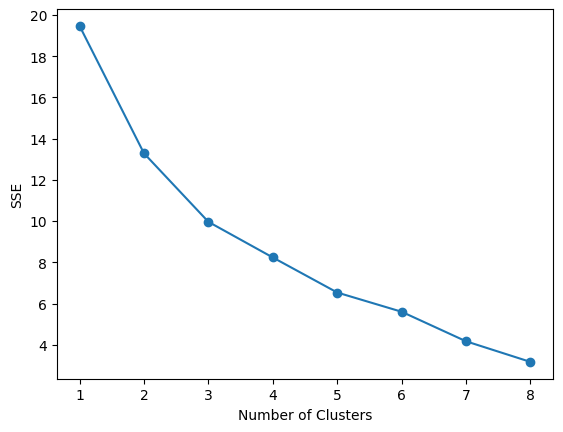

In [ ]:
numClusters = [1,2,3,4,5,6,7,8]
SSE = []
for k in numClusters:  # k取值1~8，做kmeans聚类，看不同k值对应的簇内误差平方和
    k_means = cluster.KMeans(n_clusters=k)
    k_means.fit(X)
    SSE.append(k_means.inertia_)  # 样本距离最近的聚类中心的距离总和

plt.plot(numClusters, SSE, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')

In [ ]:
from scipy.cluster.vq import kmeans,vq,whiten
center,_ = kmeans(whiten(X), 2)

In [ ]:

clusters,_ = vq(whiten(X),center)

In [ ]:
clusters

array([1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0], dtype=int32)

In [ ]:
center, center.shape

(array([[0.40089186, 0.40824829, 1.60356745, 0.        , 1.06066017,
         0.6363961 ],
        [2.00445931, 1.63299316, 0.        , 1.17669681, 2.12132034,
         0.84852814]]),
 (2, 6))

In [ ]:
X_km=cluster.KMeans(n_clusters=2).fit(X)
X_km.labels_

array([1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0], dtype=int32)

In [ ]:
cluster_by_Kmeans=pd.concat([vertebrate['Name'], pd.DataFrame(X_km.labels_,columns=['cluster'])],axis=1)
cluster_by_Kmeans.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Name,human,python,salmon,whale,frog,komodo,bat,pigeon,cat,leopard shark,turtle,penguin,porcupine,eel,salamander
cluster,1,0,0,0,0,0,1,1,1,0,0,0,1,0,0


In [ ]:
X_km.cluster_centers_

array([[0.2, 0.2, 0.8, 0. , 0.5, 0.3],
       [1. , 0.8, 0. , 0.4, 1. , 0.4]])

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6521/2189761625.py:21: SyntaxWarning: invalid escape sequence '\s'
  basketball_data = pd.read_csv(io.StringIO(''.join(data_lines)), sep=',\s*|\s+', header=None, engine='python')


Basketball data head:
        0    1      2   3       4
0  0.0888  201  36.02  28  0.5885
1  0.1399  198  39.32  30  0.8291
2  0.0747  198  38.80  26  0.4974
3  0.0983  191  40.71  30  0.5772
4  0.1276  196  38.40  28  0.5703
Basketball data shape: (96, 5)


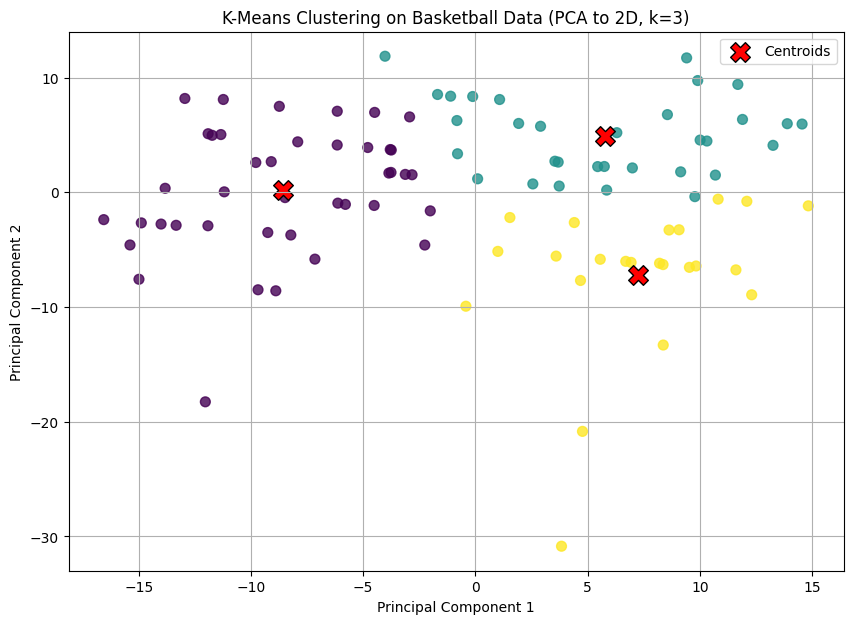


Cluster Labels:
0    41
1    32
2    23
Name: count, dtype: int64

Cluster Centroids:
          0           1          2          3         4
0  0.154173  188.731707  17.482927  27.073171  0.365049
1  0.130803  195.656250  30.835938  28.656250  0.477372
2  0.216387  183.869565  34.222174  27.652174  0.439252


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import io

file_path = '/content/drive/MyDrive/04399_Big_Data_Analytics&Mining_Tech/data/basketball.txt'
data_start_found = False
data_lines = []

with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip() == '@data':
            data_start_found = True
            continue # Skip the @data line itself
        if data_start_found:
            data_lines.append(line)

basketball_data = pd.read_csv(io.StringIO(''.join(data_lines)), sep=',\s*|\s+', header=None, engine='python')


for col in basketball_data.columns:
    if basketball_data[col].dtype == 'object':
        basketball_data[col] = basketball_data[col].astype(str).str.replace(',', '', regex=False)

    basketball_data[col] = pd.to_numeric(basketball_data[col], errors='coerce')


basketball_data = basketball_data.dropna(how='all')

print("Basketball data head:")
print(basketball_data.head())
print("Basketball data shape:", basketball_data.shape)

# 使用所有列进行聚类
X_basketball = basketball_data.copy()

# 确定聚类数量。为了可视化，我们从3个簇开始。
n_clusters = 3

# 2. 应用 K-means 聚类
kmeans_basketball = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_basketball.fit(X_basketball)
labels_basketball = kmeans_basketball.labels_
centroids_basketball = kmeans_basketball.cluster_centers_

# 3. 可视化结果
plt.figure(figsize=(10, 7))

# 如果数据维度超过2维，使用PCA进行可视化
if X_basketball.shape[1] > 2:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_basketball)
    centroids_pca = pca.transform(centroids_basketball)

    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_basketball, cmap='viridis', s=50, alpha=0.8)
    plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='red', edgecolors='black', label='Centroids')
    plt.title(f'K-Means Clustering on Basketball Data (PCA to 2D, k={n_clusters})')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
else: # 如果数据有2维或更少
    plt.scatter(X_basketball.iloc[:, 0], X_basketball.iloc[:, 1], c=labels_basketball, cmap='viridis', s=50, alpha=0.8)
    plt.scatter(centroids_basketball[:, 0], centroids_basketball[:, 1], marker='X', s=200, c='red', edgecolors='black', label='Centroids')
    plt.title(f'K-Means Clustering on Basketball Data (k={n_clusters})')
    plt.xlabel(f'Feature {basketball_data.columns[0]}')
    plt.ylabel(f'Feature {basketball_data.columns[1]}')

plt.legend()
plt.grid(True)
plt.show()

print("\nCluster Labels:")
print(pd.Series(labels_basketball).value_counts().sort_index())
print("\nCluster Centroids:")
print(pd.DataFrame(centroids_basketball, columns=X_basketball.columns))

### 聚类价值分析：特征分布可视化
通过可视化每个特征在不同聚类中的分布，我们可以更直观地理解每个簇的特点。这将帮助我们识别每个球员类型（簇）的关键属性。

/tmp/ipykernel_6521/2824063709.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=basketball_data_clustered, ax=axes[i], palette='viridis')
/tmp/ipykernel_6521/2824063709.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=basketball_data_clustered, ax=axes[i], palette='viridis')
/tmp/ipykernel_6521/2824063709.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=basketball_data_clustered, ax=axes[i], palette='viridis')
/tmp/ipykernel_6521/2824063709.py:14: FutureWa

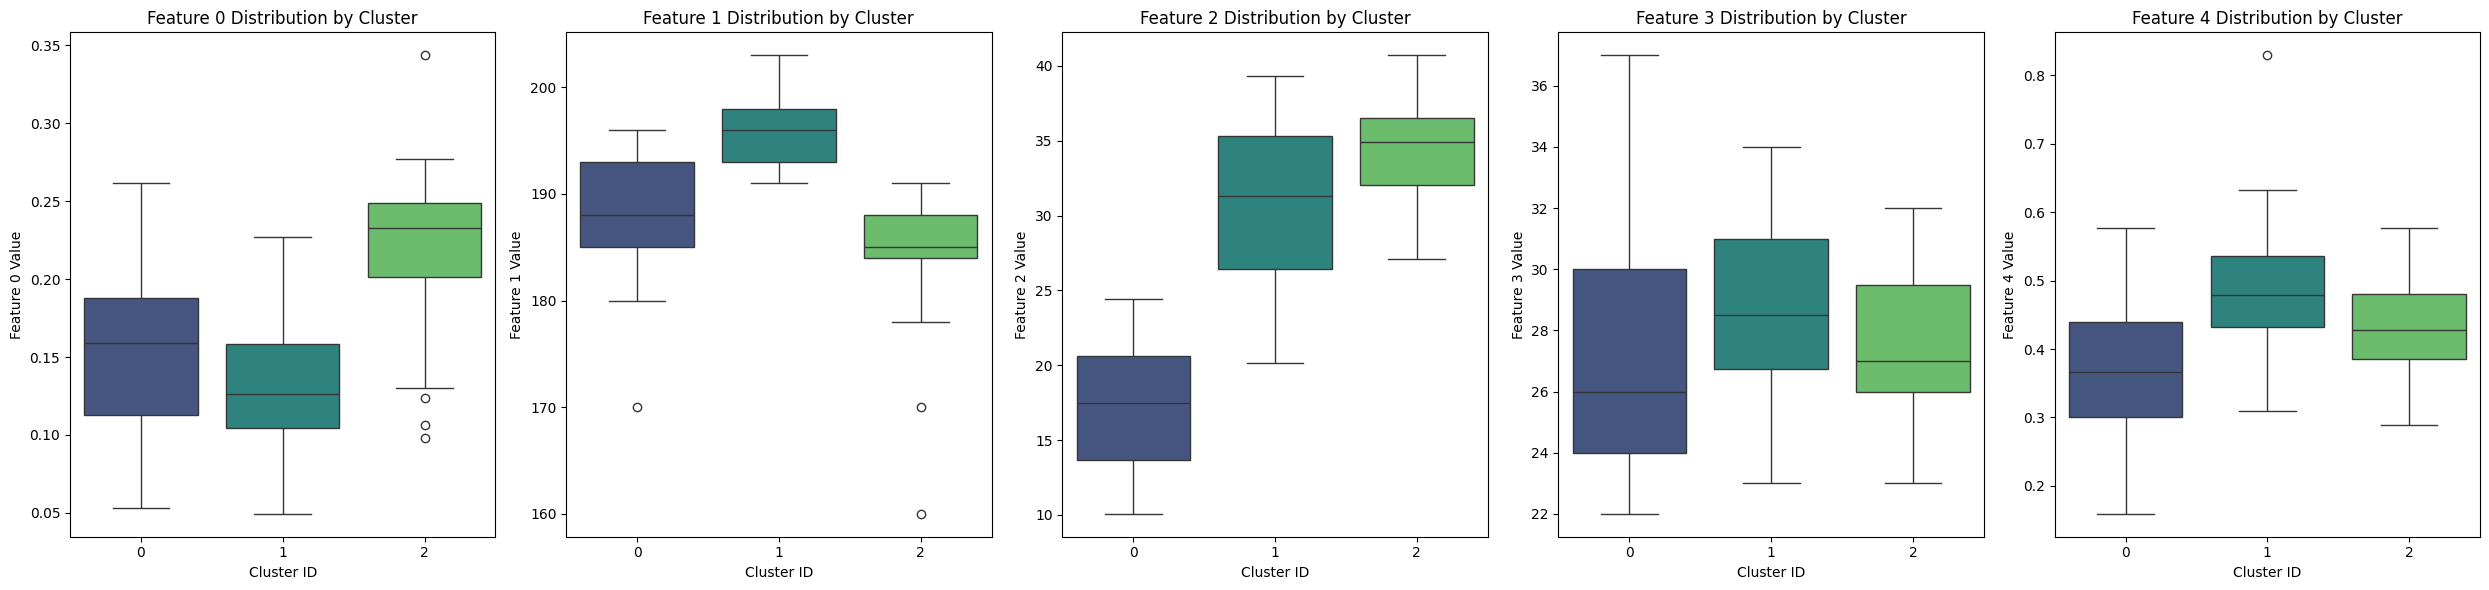

In [ ]:
# 将聚类标签添加到原始数据中，便于按簇分析
import seaborn as sns # Import seaborn for boxplot
basketball_data_clustered = X_basketball.copy()
basketball_data_clustered['Cluster'] = labels_basketball

# 为每个特征创建箱线图，以可视化其在不同簇中的分布
num_features = X_basketball.shape[1]
fig, axes = plt.subplots(nrows=1, ncols=num_features, figsize=(5 * num_features, 6))

if num_features == 1: # 如果只有一个特征，axes不是数组
    axes = [axes]

for i, col in enumerate(X_basketball.columns):
    sns.boxplot(x='Cluster', y=col, data=basketball_data_clustered, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Feature {col} Distribution by Cluster')
    axes[i].set_xlabel('Cluster ID')
    axes[i].set_ylabel(f'Feature {col} Value')

plt.tight_layout()
plt.show()